=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   voltage_v                     5000 non-null   float64
 1   current_a                     5000 non-null   float64
 2   active_power_kw               5000 non-null   float64
 3   reactive_power_kvar           5000 non-null   float64
 4   load_demand_kwh               5000 non-null   float64
 5   household_type                5000 non-null   object 
 6   occupancy_level               5000 non-null   int64  
 7   appliance_usage_category      5000 non-null   object 
 8   deviation_neighborhood_ratio  5000 non-null   float64
 9   zero_consumption_flag         5000 non-null   int64  
 10  load_spike_flag               5000 non-null   int64  
 11  fraudulent                    5000 non-null   int64  
 12  broader_zone                  5000 non-null 

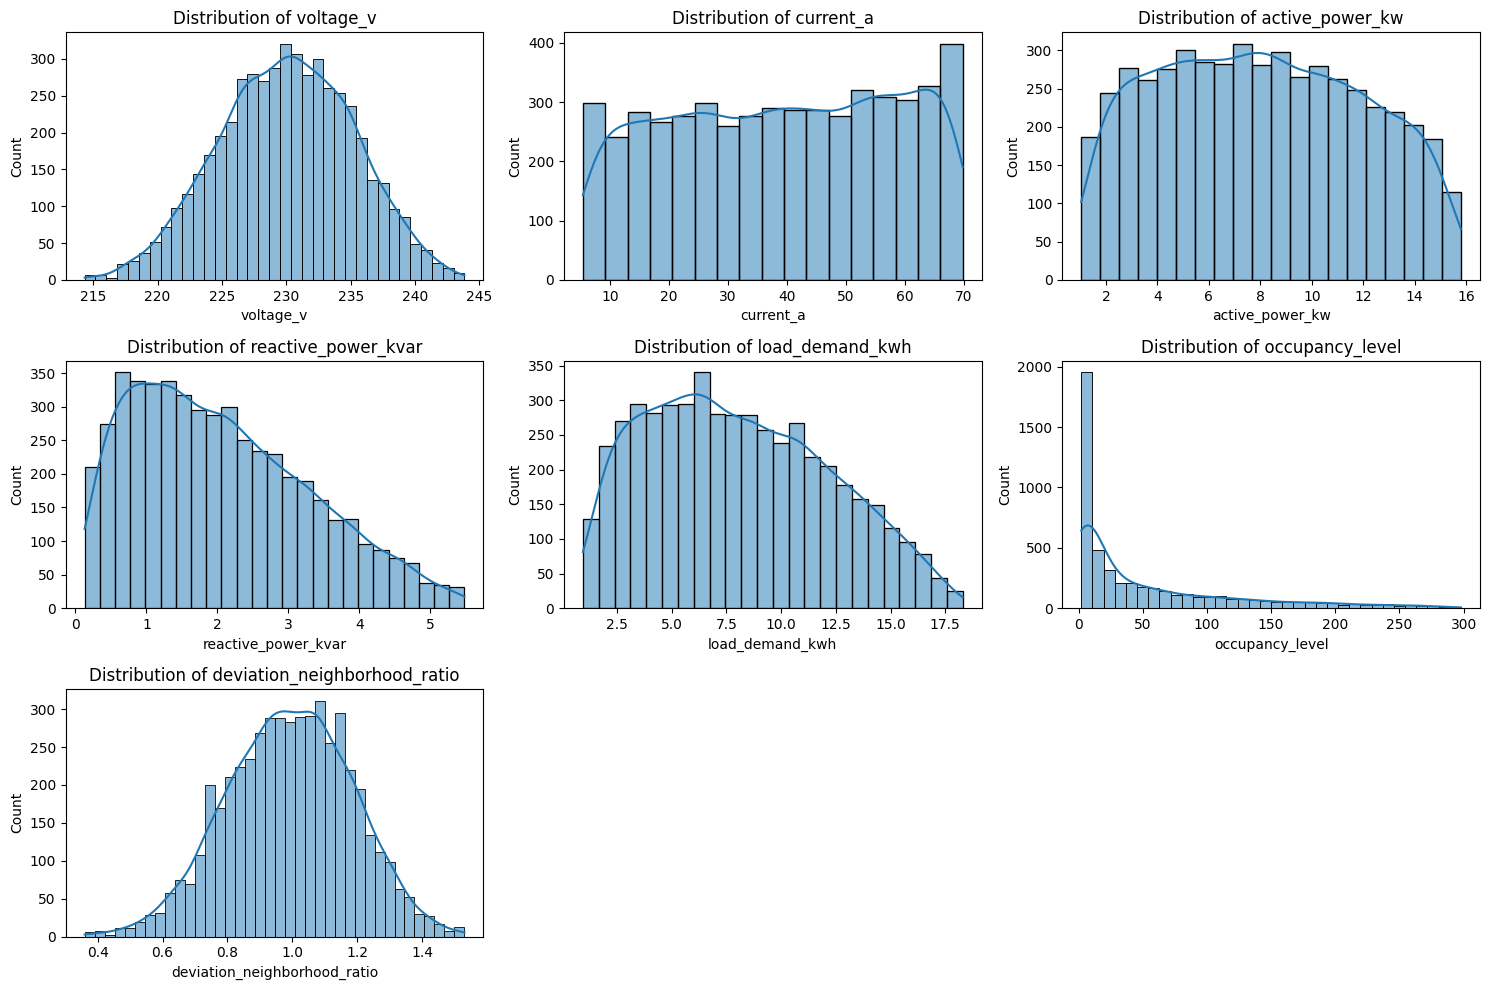

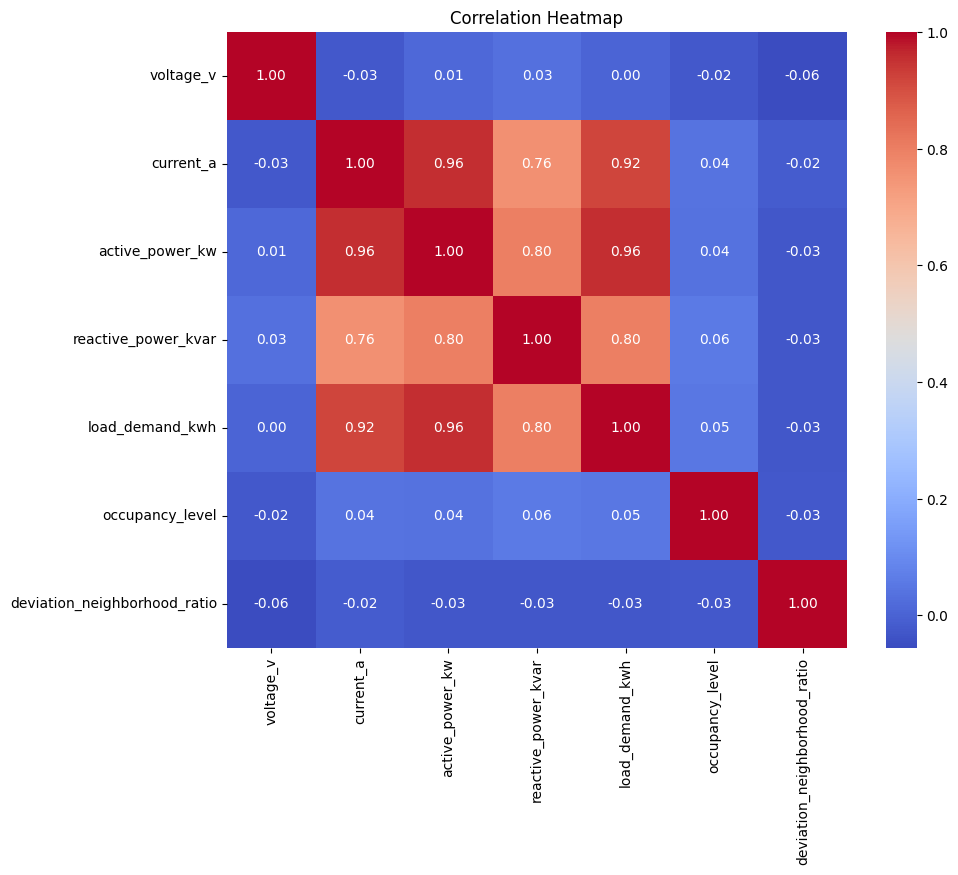

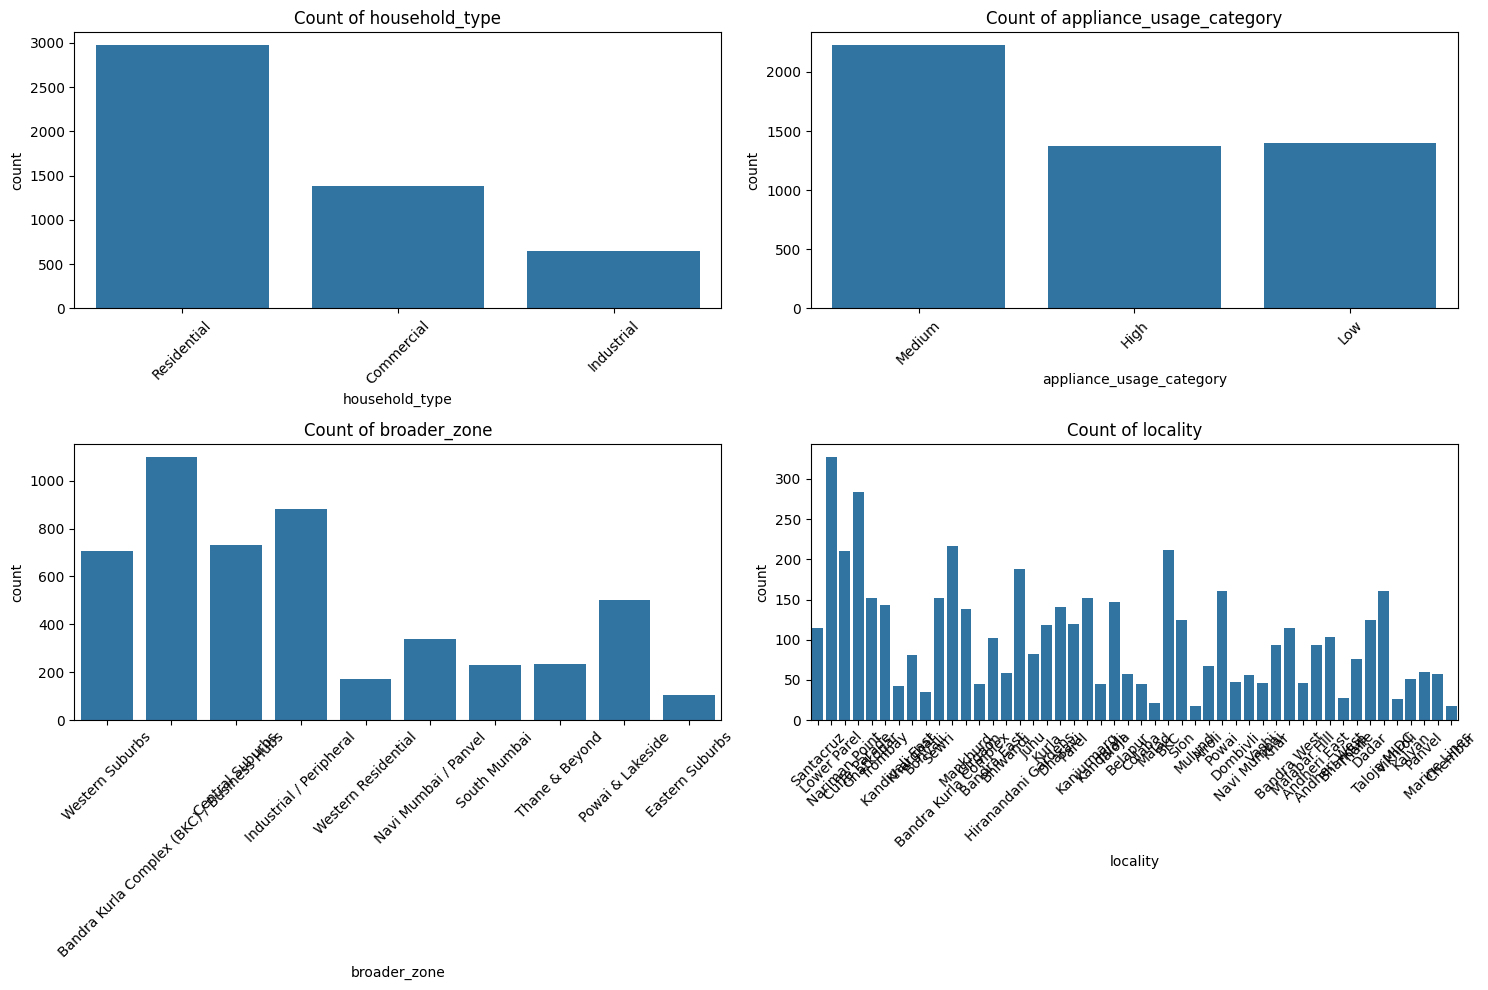


=== Model Evaluation ===
Accuracy: 0.939

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       804
           1       0.90      0.77      0.83       196

    accuracy                           0.94      1000
   macro avg       0.93      0.88      0.90      1000
weighted avg       0.94      0.94      0.94      1000


Confusion Matrix:
[[788  16]
 [ 45 151]]

=== Feature Importance ===
                         Feature  Importance
11                  broader_zone    0.336708
12                      locality    0.210448
8   deviation_neighborhood_ratio    0.050400
0                      voltage_v    0.049814
4                load_demand_kwh    0.047588
10               load_spike_flag    0.047373
9          zero_consumption_flag    0.046657
2                active_power_kw    0.045052
3            reactive_power_kvar    0.044639
1                      current_a    0.043686
6                occupancy_level    0.0392

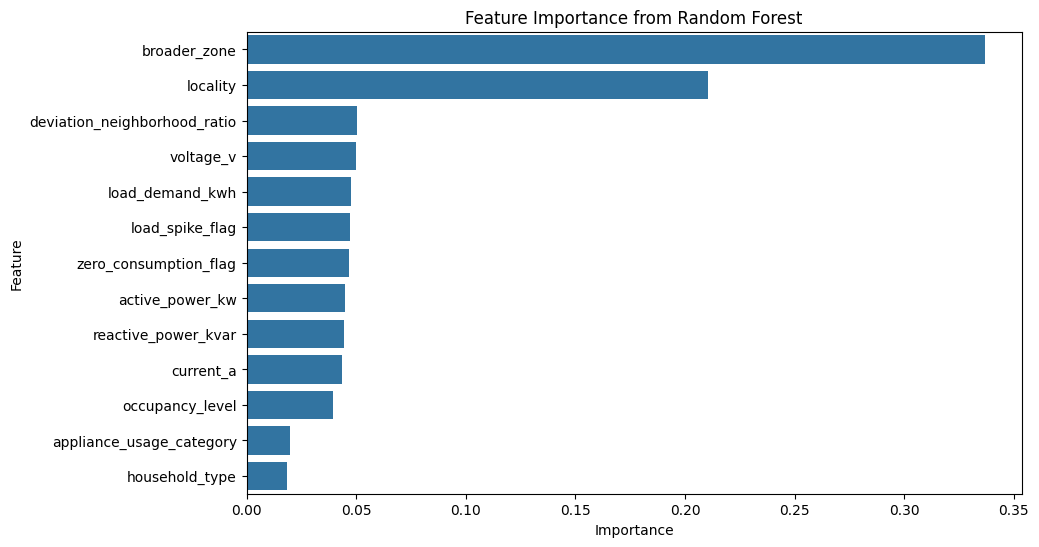

In [ ]:
# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

# =========================
# LOAD DATA
# =========================
data = pd.read_csv("fraud_balance/syn_fraud.csv")

# =========================
# CREATE STRONG FRAUD SIGNAL
# =========================
data['fraudulent'] = 0

fraud_condition = (
    (data['load_demand_kwh'] > 70) &
    (data['deviation_neighborhood_ratio'] > 2.0) &
    (data['current_a'] > 18)
)

data.loc[fraud_condition, 'fraudulent'] = 1

# =========================
# BOOST FRAUD SAMPLES
# =========================
fraud_samples = data[data['fraudulent'] == 1].copy()

# Make fraud more extreme (clear separation)
fraud_samples['load_demand_kwh'] *= 1.8
fraud_samples['deviation_neighborhood_ratio'] *= 2.5
fraud_samples['current_a'] *= 1.5
fraud_samples['active_power_kw'] *= 1.5

# Duplicate fraud to balance dataset
data = pd.concat([data, fraud_samples, fraud_samples], ignore_index=True)

# =========================
# FEATURES
# =========================
numerical_cols = [
    'voltage_v', 'current_a', 'active_power_kw',
    'reactive_power_kvar', 'load_demand_kwh',
    'occupancy_level', 'deviation_neighborhood_ratio'
]

categorical_cols = [
    'household_type', 'appliance_usage_category',
    'broader_zone', 'locality'
]

# =========================
# ENCODE CATEGORICAL
# =========================
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# =========================
# SPLIT DATA
# =========================
X = data.drop('fraudulent', axis=1)
y = data['fraudulent']

# Scale numerical features
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# TRAIN MODEL
# =========================
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

# =========================
# EVALUATION
# =========================
y_pred = model.predict(X_test)

print("\n=== MODEL PERFORMANCE ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# =========================
# FEATURE IMPORTANCE (optional)
# =========================
importances = pd.Series(model.feature_importances_, index=X.columns)
print("\nTop Features:\n", importances.sort_values(ascending=False).head(5))

# =========================
# SAVE EVERYTHING
# =========================
joblib.dump(model, 'static/fraud_model_local.joblib')
joblib.dump(scaler, 'static/scaler.joblib')
joblib.dump(label_encoders, 'static/encoders.joblib')

print("\n✅ Model saved successfully!")